## We study the effective connection of a Ferromagnetic Chain in a 2-sites case

#### Create the graph

In [1]:
import numpy as np
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import networkx as nx
import matplotlib.pyplot as plt

from src.utils import computational_basis

physical_qubits = 3
nqubits = 2
gamma = 100
ferromagnetic_coupling = 100
delta2 = gamma
alpha = 1

g_matrix = -alpha * np.ones((nqubits, nqubits)) + np.eye(nqubits)
print(g_matrix)
diagonal_couplings = np.array([-0.9, -0.1])

[[ 0. -1.]
 [-1.  0.]]


#### Corresponding XY model

In [38]:
hamiltonian_xy = 0.0
for i in range(nqubits):
    for j in range(i + 1, nqubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=nqubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=nqubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0

for i in range(nqubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_couplings[i]], size=nqubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [39]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [40]:
print("Eigenvalues of the NSM quasiparticle Hamiltonian:")
print(eigenvalues_nsm)

Eigenvalues of the NSM quasiparticle Hamiltonian:
[-1.57703296 -1.          0.          0.57703296]


I want to look at the components of the many-body wavefunction

In [41]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=nqubits).qutip_op
    for i in range(nqubits)
)
print(N_op.shape)

# shape (2**nqubits, nqubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 1
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N1 = eigenvalues_nsm[sector_indices]
eigenstates_N1 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=1 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N1 = eigenstates_nsm[idx]
ground_eigenvalue_N1 = eigenvalues_nsm[idx]

print("Ground state energy in N=1 sector:", ground_eigenvalue_N1)
print("Ground state in N=1 sector (in computational basis):")

(4, 4)
Ground state energy in N=1 sector: -1.5770329614268999
Ground state in N=1 sector (in computational basis):


I get also the probabilities


   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
          01    0.31430    0.56063    0.00000
          10    0.68570    0.82807    0.00000


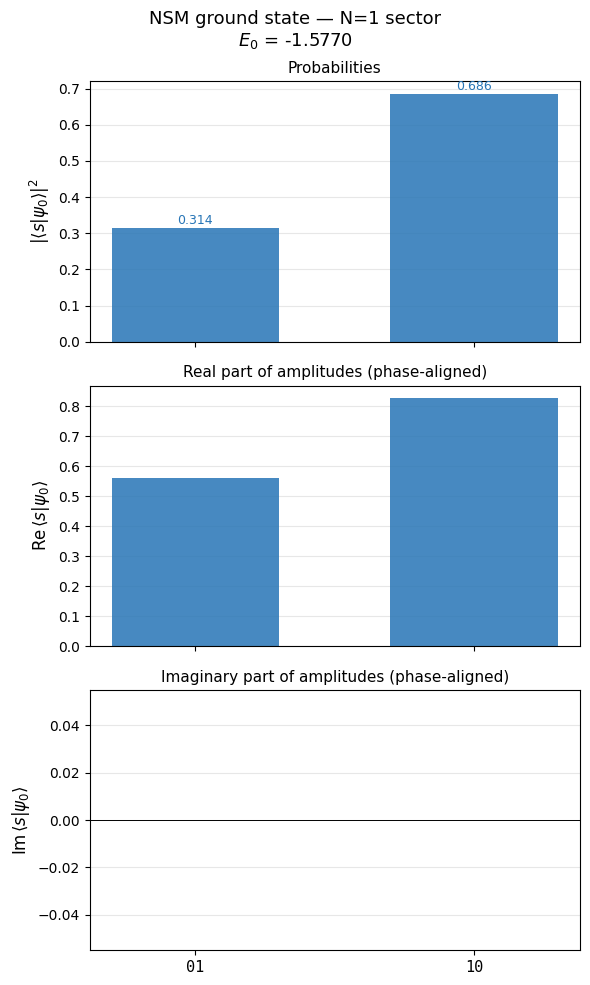

In [42]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N1.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=1 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(nqubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_n1 = probs[n1_mask]
re_n1 = re[n1_mask]
im_n1 = im[n1_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n1, probs_n1, re_n1, im_n1):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n1))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n1) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=1 sector\n" f"$E_0$ = {ground_eigenvalue_N1:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n1, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n1):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

In [43]:
print(eigenvalues_nsm)
gs_idx = np.argmin(np.abs(eigenvalues_nsm - ground_eigenvalue_N1))
print(eigenstates_nsm[gs_idx].full())
print(gs_idx)

[-1.57703296 -1.          0.          0.57703296]
[[0.        +0.j]
 [0.56062881+0.j]
 [0.82806723+0.j]
 [0.        +0.j]]
0


The gadget

In [44]:
longitudinal_hamiltonian = 0.0

# the copy and the other logical qubits have the particle conservation constrain
for i in [1, 2]:
    longitudinal_hamiltonian += SpinOperator(
        [("qz", i)],
        coupling=[gamma * (1 - 2)],  # = -gamma, from expanding (N-1)^2
        size=physical_qubits,
        verbose=1,
    ).qutip_op

# Quadratic Nc terms: 2*gamma * Ni * Nj  for each intra-triangle pair
longitudinal_hamiltonian += SpinOperator(
    [("z", 0, "z", 1)],
    coupling=[-ferromagnetic_coupling],
    size=physical_qubits,
    verbose=1,
).qutip_op

# copy constrain with ferromagnetic coupling
longitudinal_hamiltonian += SpinOperator(
    [("qz", 1, "qz", 2)],
    coupling=[2 * gamma],  # same coefficient gamma
    size=physical_qubits,
    verbose=1,
).qutip_op

# we add the external field... NEXT TIME
for r, i in enumerate([0, 2]):

    longitudinal_hamiltonian += SpinOperator(
        [("qz", i)],
        coupling=[diagonal_couplings[r] / (gamma)],
        size=physical_qubits,
        verbose=1,
    ).qutip_op

# --- Identity shift: +gamma per triangle (4 triangles) to complete the (N-1)^2 expansion
longitudinal_hamiltonian += (ferromagnetic_coupling + gamma) * qt.tensor(
    [qt.qeye(2)] * (physical_qubits)
)

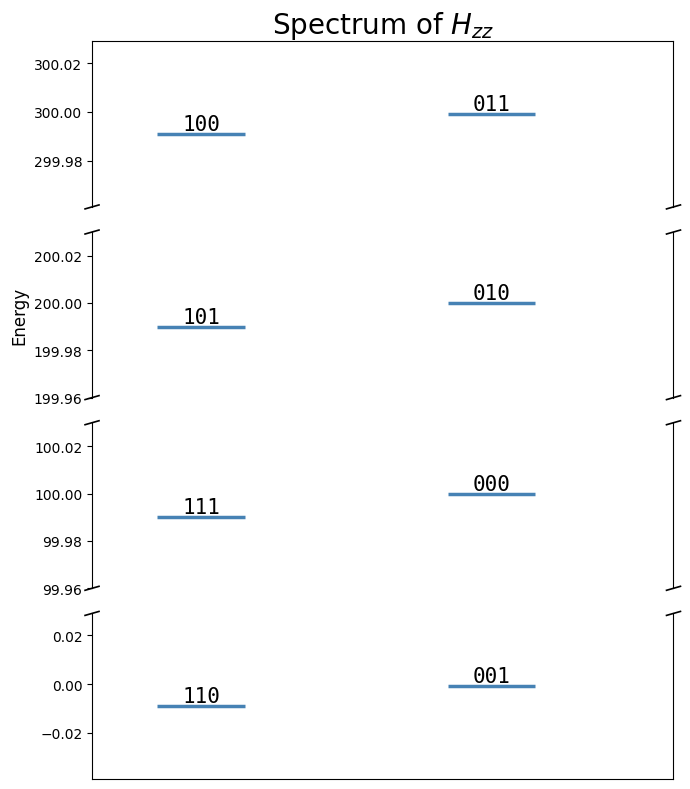

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


#### this should go to the utils
def plot_spectrum(energies, basis, gap_threshold=0.3, figsize=(7, 8)):
    """
    Plot energy spectrum with broken axis to show both small splittings
    and large gaps between subspaces.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    gap_threshold : float
        Fraction of max gap used to detect subspace boundaries.
    figsize : tuple
    """
    labels = ["".join(map(str, row)) for row in basis]
    order = np.argsort(energies)
    sorted_energies = energies[order]
    sorted_labels = [labels[i] for i in order]

    # --- detect subspaces from large gaps ---
    gaps = np.diff(sorted_energies)
    max_gap = gaps.max()
    boundaries = np.where(gaps > gap_threshold * max_gap)[0]
    splits = np.split(np.arange(len(sorted_energies)), boundaries + 1)

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=figsize,
        gridspec_kw={"height_ratios": heights},
        squeeze=False,
    )
    axes = axes.flatten()
    splits = splits[::-1]

    for ax, group in zip(axes, splits):

        es = sorted_energies[group]
        ls = [sorted_labels[i] for i in group]
        n = len(es)

        # stagger x positions to avoid label overlap
        x_positions = np.linspace(0.15, 0.55, max(n, 1))

        for x, e, label in zip(x_positions, es, ls):
            ax.hlines(e, x - 0.06, x + 0.06, linewidth=2.5, color="steelblue")
            ax.text(
                x,
                e,
                label,
                va="bottom",
                ha="center",
                fontsize=15,
                fontfamily="monospace",
            )

        span = es.max() - es.min()
        margin = max(span * 0.6, 0.03)
        ax.set_ylim(es.min() - margin, es.max() + margin)
        ax.set_xlim(0, 0.8)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines["top"].set_visible(False)

    # break marks between panels
    d = 0.012
    for ax_bot, ax_top in zip(axes[1:], axes[:-1]):
        for ax, y in [(ax_bot, 1), (ax_top, 0)]:
            kw = dict(color="k", clip_on=False, linewidth=1.2, transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    axes[1].set_ylabel("Energy", fontsize=12)
    axes[0].set_title(r"Spectrum of $H_{zz}$", fontsize=20)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    axes[0].yaxis.set_major_formatter(formatter)
    axes[1].yaxis.set_major_formatter(formatter)
    axes[2].yaxis.set_major_formatter(formatter)
    plt.tight_layout()
    plt.show()


basis = computational_basis(physical_qubits)
plot_spectrum(longitudinal_hamiltonian.diag(), basis)

In [46]:
transverse_hamiltonian = 0.0

for r, i in enumerate([0, 2]):
    print(f"Adding transverse field on qubit {i} with strength {np.sqrt(alpha)}")
    transverse_hamiltonian += SpinOperator(
        [("x", i)],
        coupling=[np.sqrt(alpha) / np.sqrt(2)],
        size=physical_qubits,
        verbose=1,
    ).qutip_op

transverse_hamiltonian += SpinOperator(
    [("x", 1)],
    coupling=[ferromagnetic_coupling],
    size=physical_qubits,
    verbose=1,
).qutip_op


total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian

eigenvalues, eigenstates = total_hamiltonian.eigenstates()
print(eigenvalues)

for i in range(basis.shape[0]):
    print(f"{basis[i]}: {eigenstates[0].full()[i]**2}")

Adding transverse field on qubit 0 with strength 1.0
Adding transverse field on qubit 2 with strength 1.0
[-30.30511506 -30.28358078  38.19048304  38.21283732 261.77716268
 261.79951696 330.27358078 330.29511506]
[0 0 0]: [9.39539575e-05+0.j]
[0 0 1]: [0.28776137+0.j]
[0 1 0]: [5.09875396e-05+0.j]
[0 1 1]: [0.02638801-0.j]
[1 0 0]: [0.05757843+0.j]
[1 0 1]: [4.83077311e-05-0.j]
[1 1 0]: [0.62796834-0.j]
[1 1 1]: [0.0001106+0.j]


/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


([<matplotlib.axis.XTick at 0x7a925bc96210>,
 [Text(0, 0, '000'),
  Text(1, 0, '001'),
  Text(2, 0, '010'),
  Text(3, 0, '011'),
  Text(4, 0, '100'),
  Text(5, 0, '101'),
  Text(6, 0, '110'),
  Text(7, 0, '111')])

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


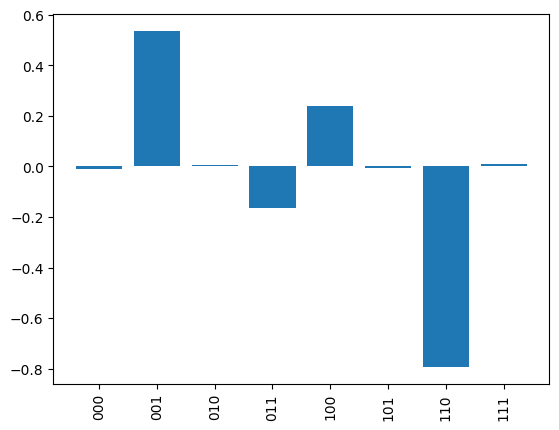

In [47]:
plt.bar(range(basis.shape[0]), eigenstates[0].full().flatten())
plt.xticks(
    range(basis.shape[0]), ["".join(map(str, row)) for row in basis], rotation=90
)

## We study the effective connection of a Ferromagnetic Chain in a 3-sites case

#### Create the graph

In [306]:
import numpy as np
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import networkx as nx
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from src.utils import computational_basis

physical_qubits = 6
nqubits = 3
gamma = 20
ferromagnetic_coupling = 5
delta2 = gamma
alpha = 1

data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_p.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
n_qubits = 3

g_onebody = {}
diagonal_elements = np.zeros(n_qubits)
g_matrix = np.zeros((n_qubits, n_qubits))
for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]


# get the computational basis of the space
basis = computational_basis(n_qubits)
print(g_matrix)
diagonal_couplings = 0.0 * np.array([-0.9, -0.1, -0.3])

[[ 0.          1.0431     -3.76385869]
 [ 1.0431      0.          3.76385869]
 [-3.76385869  3.76385869  0.        ]]


Optimal drive parameters: [ 1.02132267 -1.02132267  3.6852787 ]
Optimized effective interaction matrix:
 [[ 0.00000000e+00 -7.10542736e-15 -3.10862447e-15]
 [-7.10542736e-15  0.00000000e+00  8.88178420e-15]
 [-3.10862447e-15  8.88178420e-15  0.00000000e+00]]


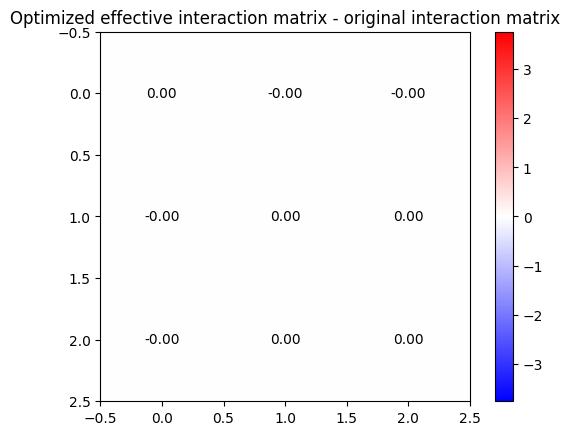

TypeError: 'Figure' object is not subscriptable

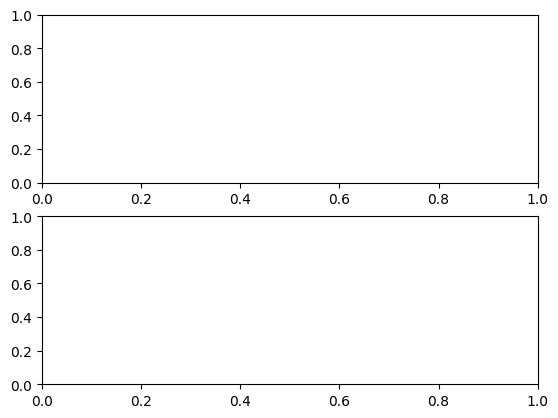

In [ ]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=n_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()
fig, ax = plt.subplots(2, 1)

ax[0].imshow(
    OptimalFieldBe6.reconstructed(d_opt),
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
ax[0].colorbar()
ax[0].title("Optimized effective interaction matrix ")

ax[1].imshow(
    g_matrix, cmap="bwr", vmin=-np.max(np.abs(g_matrix)), vmax=np.max(np.abs(g_matrix))
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(j, i, f"{g_matrix[i,j]:.2f}", ha="center", va="center", color="black")
ax[1].colorbar()
ax[1].title("one-quasiparticle interaction matrix ")
plt.show()

Corresponding XY model

In [308]:
hamiltonian_xy = 0.0
for i in range(nqubits):
    for j in range(i + 1, nqubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=nqubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=nqubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0

for i in range(nqubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_couplings[i]], size=nqubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [309]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [310]:
print("Eigenvalues of the NSM quasiparticle Hamiltonian:")
print(eigenvalues_nsm)

Eigenvalues of the NSM quasiparticle Hamiltonian:
[-5.8699403 -5.8699403  0.         0.         1.0431     1.0431
  4.8268403  4.8268403]


In [311]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=nqubits).qutip_op
    for i in range(nqubits)
)
print(N_op.shape)

# shape (2**nqubits, nqubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 1
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N1 = eigenvalues_nsm[sector_indices]
eigenstates_N1 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=1 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N1 = eigenstates_nsm[idx]
ground_eigenvalue_N1 = eigenvalues_nsm[idx]

print("Ground state energy in N=1 sector:", ground_eigenvalue_N1)
print("Ground state in N=1 sector (in computational basis):")

(8, 8)
Ground state energy in N=1 sector: -5.869940301062546
Ground state in N=1 sector (in computational basis):



   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
         001    0.45124    0.67175    0.00000
         010    0.27438   -0.52381    0.00000
         100    0.27438    0.52381    0.00000


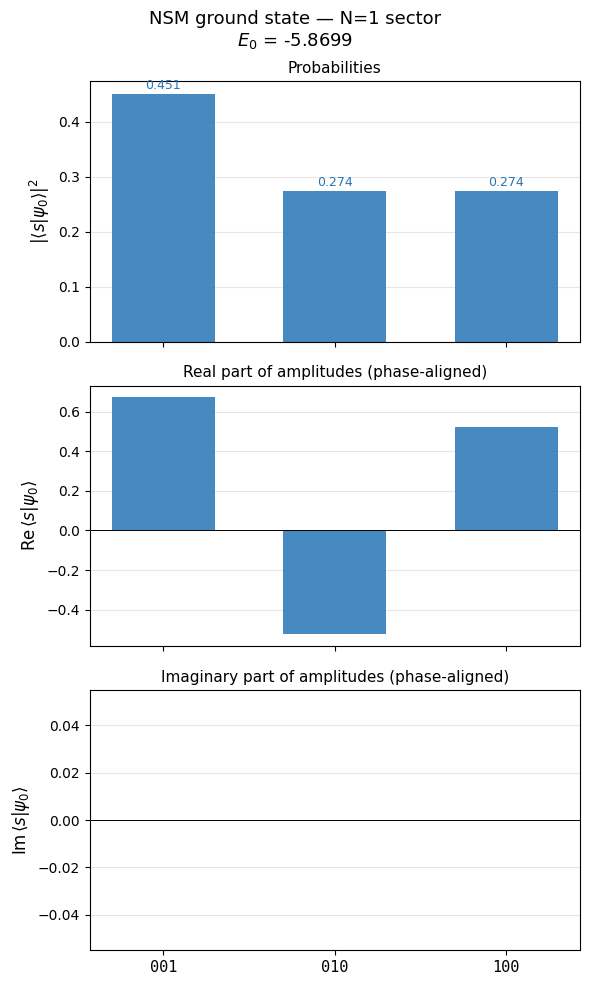

In [312]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N1.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=1 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(nqubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_n1 = probs[n1_mask]
re_n1 = re[n1_mask]
im_n1 = im[n1_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n1, probs_n1, re_n1, im_n1):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n1))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n1) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=1 sector\n" f"$E_0$ = {ground_eigenvalue_N1:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n1, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n1):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

In [313]:
print(eigenvalues_nsm)
gs_idx = np.argmin(np.abs(eigenvalues_nsm - ground_eigenvalue_N1))
print(eigenstates_nsm[gs_idx].full())
print(gs_idx)

[-5.8699403 -5.8699403  0.         0.         1.0431     1.0431
  4.8268403  4.8268403]
[[ 0.        +0.j]
 [ 0.67174574+0.j]
 [-0.52381183+0.j]
 [ 0.        +0.j]
 [ 0.52381183+0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]
 [ 0.        +0.j]]
1


The gadget

In [314]:
longitudinal_hamiltonian = 0.0

# the copy and the other logical qubits have the particle conservation constrain
for i in [0, 1, 2, 3, 4, 5]:
    longitudinal_hamiltonian += SpinOperator(
        [("qz", i)],
        coupling=[0.5 * gamma * (1 - 2)],  # = -gamma, from expanding (N-1)^2
        size=physical_qubits,
        verbose=1,
    ).qutip_op


# Quadratic Nc terms: 2*gamma * Ni * Nj  for each intra-triangle pair
longitudinal_hamiltonian += SpinOperator(
    [("z", 0, "z", 3)],
    coupling=[-ferromagnetic_coupling],
    size=physical_qubits,
    verbose=1,
).qutip_op

longitudinal_hamiltonian += SpinOperator(
    [("z", 1, "z", 4)],
    coupling=[-ferromagnetic_coupling],
    size=physical_qubits,
    verbose=1,
).qutip_op

longitudinal_hamiltonian += SpinOperator(
    [("z", 2, "z", 5)],
    coupling=[-ferromagnetic_coupling],
    size=physical_qubits,
    verbose=1,
).qutip_op


for i in range(nqubits):

    for j in range(nqubits):
        if i != j:
            print(f"Adding coupling between qubits {i} and {j+3} with strength {gamma}")
            # copy constrain with ferromagnetic coupling
            longitudinal_hamiltonian += SpinOperator(
                [("qz", i, "qz", j + 3)],
                coupling=[gamma],  # same coefficient gamma
                size=physical_qubits,
                verbose=1,
            ).qutip_op
# we add the external field... NEXT TIME
for r, i in enumerate([0, 1, 2]):

    longitudinal_hamiltonian += SpinOperator(
        [("qz", i)],
        coupling=[diagonal_couplings[r] / (2 * gamma)],
        size=physical_qubits,
        verbose=1,
    ).qutip_op

# --- Identity shift: +gamma per triangle (4 triangles) to complete the (N-1)^2 expansion
longitudinal_hamiltonian += (ferromagnetic_coupling + gamma) * qt.tensor(
    [qt.qeye(2)] * (physical_qubits)
)

Adding coupling between qubits 0 and 4 with strength 20
Adding coupling between qubits 0 and 5 with strength 20
Adding coupling between qubits 1 and 3 with strength 20
Adding coupling between qubits 1 and 5 with strength 20
Adding coupling between qubits 2 and 3 with strength 20
Adding coupling between qubits 2 and 4 with strength 20


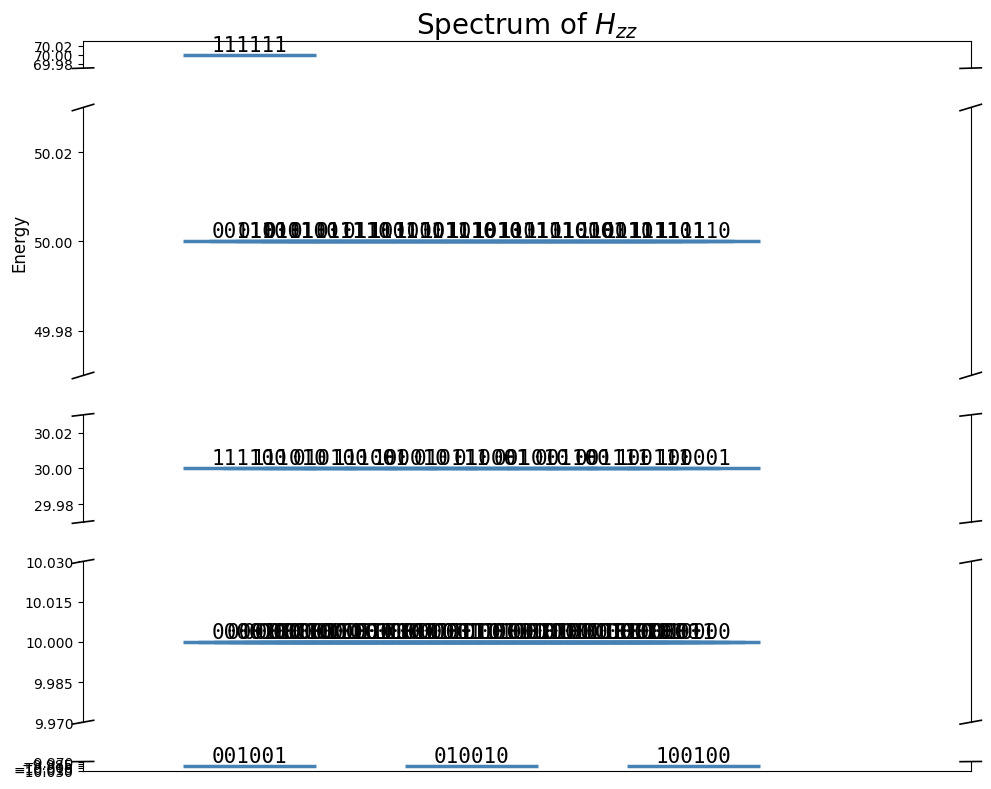

In [315]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


#### this should go to the utils
def plot_spectrum(energies, basis, gap_threshold=0.3, figsize=(10, 8)):
    """
    Plot energy spectrum with broken axis to show both small splittings
    and large gaps between subspaces.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    gap_threshold : float
        Fraction of max gap used to detect subspace boundaries.
    figsize : tuple
    """
    labels = ["".join(map(str, row)) for row in basis]
    order = np.argsort(energies)
    sorted_energies = energies[order]
    sorted_labels = [labels[i] for i in order]

    # --- detect subspaces from large gaps ---
    gaps = np.diff(sorted_energies)
    max_gap = gaps.max()
    boundaries = np.where(gaps > gap_threshold * max_gap)[0]
    splits = np.split(np.arange(len(sorted_energies)), boundaries + 1)

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=figsize,
        gridspec_kw={"height_ratios": heights},
        squeeze=False,
    )
    axes = axes.flatten()
    splits = splits[::-1]

    for ax, group in zip(axes, splits):

        es = sorted_energies[group]
        ls = [sorted_labels[i] for i in group]
        n = len(es)

        # stagger x positions to avoid label overlap
        x_positions = np.linspace(0.15, 0.55, max(n, 1))

        for x, e, label in zip(x_positions, es, ls):
            ax.hlines(e, x - 0.06, x + 0.06, linewidth=2.5, color="steelblue")
            ax.text(
                x,
                e,
                label,
                va="bottom",
                ha="center",
                fontsize=15,
                fontfamily="monospace",
            )

        span = es.max() - es.min()
        margin = max(span * 0.6, 0.03)
        ax.set_ylim(es.min() - margin, es.max() + margin)
        ax.set_xlim(0, 0.8)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines["top"].set_visible(False)

    # break marks between panels
    d = 0.012
    for ax_bot, ax_top in zip(axes[1:], axes[:-1]):
        for ax, y in [(ax_bot, 1), (ax_top, 0)]:
            kw = dict(color="k", clip_on=False, linewidth=1.2, transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    axes[1].set_ylabel("Energy", fontsize=12)
    axes[0].set_title(r"Spectrum of $H_{zz}$", fontsize=20)

    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    axes[0].yaxis.set_major_formatter(formatter)
    axes[1].yaxis.set_major_formatter(formatter)
    axes[2].yaxis.set_major_formatter(formatter)
    plt.tight_layout()
    plt.show()


basis = computational_basis(physical_qubits)
plot_spectrum(longitudinal_hamiltonian.diag(), basis)

In [316]:
transverse_hamiltonian = 0.0

sign = d_opt / np.abs(d_opt)

for r, i in enumerate([0, 1, 2]):
    print(
        f"Adding transverse field on qubit {i} with strength {np.sqrt(np.abs(d_opt[i]))}"
    )
    transverse_hamiltonian += SpinOperator(
        [("x", i)],
        coupling=[sign[r] * np.sqrt(np.abs(d_opt[r]) * ferromagnetic_coupling / 2)],
        size=physical_qubits,
        verbose=1,
    ).qutip_op

for r, i in enumerate([3, 4, 5]):
    print(
        f"Adding transverse field on qubit {i} with strength {np.sqrt(np.abs(d_opt[r]))}"
    )
    transverse_hamiltonian += SpinOperator(
        [("x", i)],
        coupling=[np.sqrt(np.abs(d_opt[r]) * ferromagnetic_coupling / 2)],
        size=physical_qubits,
        verbose=1,
    ).qutip_op


total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian

print(total_hamiltonian)

eigenvalues, eigenstates = total_hamiltonian.eigenstates()
print(eigenvalues)

prob_sector = 0.0
for i in range(basis.shape[0]):
    if abs(eigenstates[0].full()[i]) > 0.2:
        print(
            f"{basis[i]}: {eigenstates[0].full()[i]**2}",
            "wavefunction=",
            eigenstates[0].full()[i],
        )
        prob_sector += eigenstates[0].full()[i] ** 2
print(f"Probability in the sector: {prob_sector}")

Adding transverse field on qubit 0 with strength 1.0106051018241238
Adding transverse field on qubit 1 with strength 1.0106051018241244
Adding transverse field on qubit 2 with strength 1.9197079718807093
Adding transverse field on qubit 3 with strength 1.0106051018241238
Adding transverse field on qubit 4 with strength 1.0106051018241244
Adding transverse field on qubit 5 with strength 1.9197079718807093
Quantum object: dims=[[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape=(64, 64), type='oper', dtype=CSR, isherm=True
Qobj data =
[[10.          3.03532482  1.59790697 ...  0.          0.
   0.        ]
 [ 3.03532482 10.          0.         ...  0.          0.
   0.        ]
 [ 1.59790697  0.         10.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... 50.          0.
   1.59790697]
 [ 0.          0.          0.         ...  0.         50.
   3.03532482]
 [ 0.          0.          0.         ...  1.59790697  3.03532482
  70.        ]]
[-11.5339237 

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


([<matplotlib.axis.XTick at 0x7558516eff10>,
 [Text(0, 0, '000000'),
  Text(1, 0, '000001'),
  Text(2, 0, '000010'),
  Text(3, 0, '000011'),
  Text(4, 0, '000100'),
  Text(5, 0, '000101'),
  Text(6, 0, '000110'),
  Text(7, 0, '000111'),
  Text(8, 0, '001000'),
  Text(9, 0, '001001'),
  Text(10, 0, '001010'),
  Text(11, 0, '001011'),
  Text(12, 0, '001100'),
  Text(13, 0, '001101'),
  Text(14, 0, '001110'),
  Text(15, 0, '001111'),
  Text(16, 0, '010000'),
  Text(17, 0, '010001'),
  Text(18, 0, '010010'),
  Text(19, 0, '010011'),
  Text(20, 0, '010100'),
  Text(21, 0, '010101'),
  Text(22, 0, '010110'),
  Text(23, 0, '010111'),
  Text(24, 0, '011000'),
  Text(25, 0, '011001'),
  Text(26, 0, '011010'),
  Text(27, 0, '011011'),
  Text(28, 0, '011100'),
  Text(29, 0, '011101'),
  Text(30, 0, '011110'),
  Text(31, 0, '011111'),
  Text(32, 0, '100000'),
  Text(33, 0, '100001'),
  Text(34, 0, '100010'),
  Text(35, 0, '100011'),
  Text(36, 0, '100100'),
  Text(37, 0, '100101'),
  Text(38, 0, '

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


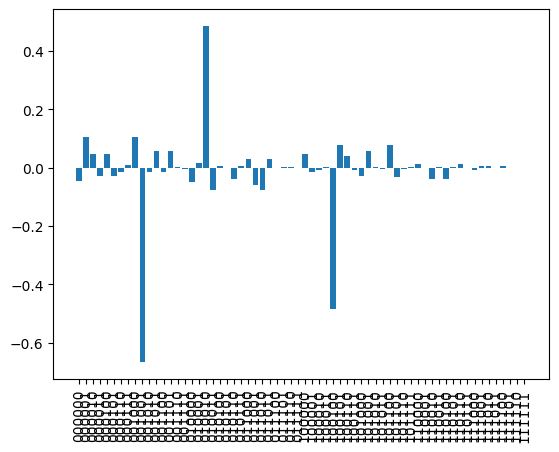

In [317]:
plt.bar(range(basis.shape[0]), eigenstates[0].full().flatten())
plt.xticks(
    range(basis.shape[0]), ["".join(map(str, row)) for row in basis], rotation=90
)